## Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

### Load Data
`load_data` figures out the file format and, for delimited text, the separator, on its own — no assumptions are hardcoded here.

In [2]:
def load_data(path):
    """
    Load a tabular data file into a pandas DataFrame without assuming its
    format or, for delimited text, its separator. Tries readers roughly in
    order of what the extension suggests, then falls through the rest —
    including generic delimiter sniffing — until one works.
    """
    import pandas as pd
    from pathlib import Path

    ext = Path(path).suffix.lower()

    def read_delimited(p):
        # sep=None + engine="python" makes pandas sniff the actual delimiter
        # (comma, semicolon, tab, pipe, whitespace, ...) from the file itself.
        return pd.read_csv(p, sep=None, engine="python")

    candidates = {
        "excel": lambda p: pd.read_excel(p),
        "json": lambda p: pd.read_json(p),
        "parquet": lambda p: pd.read_parquet(p),
        "feather": lambda p: pd.read_feather(p),
        "delimited": read_delimited,
    }

    ext_hint = {
        ".xlsx": "excel", ".xls": "excel", ".xlsm": "excel",
        ".json": "json",
        ".parquet": "parquet",
        ".feather": "feather",
    }.get(ext, "delimited")

    order = [ext_hint] + [k for k in candidates if k != ext_hint]

    errors = {}
    for key in order:
        try:
            df = candidates[key](path)
            if key != ext_hint:
                print(f"Note: '{ext}' didn't load as expected; loaded successfully as {key} instead.")
            return df
        except Exception as e:
            errors[key] = e

    raise ValueError(
        f"Could not load {path!r} with any known reader. Tried: "
        + ", ".join(f"{k} ({e.__class__.__name__})" for k, e in errors.items())
    )


In [3]:
df = load_data('data/Penguin Species Prediction Dataset.csv')
df.shape

(1000, 7)

### Initial Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            1000 non-null   object 
 1   island             1000 non-null   object 
 2   culmen_length_mm   990 non-null    float64
 3   culmen_depth_mm    990 non-null    float64
 4   flipper_length_mm  990 non-null    float64
 5   body_mass_g        990 non-null    float64
 6   sex                990 non-null    object 
dtypes: float64(4), object(3)
memory usage: 54.8+ KB


In [5]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


### Descriptive Statistics — Numerical Features

In [6]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,990.000000,990.000000,990.000000,990.000000
mean,43.817778,17.335556,199.224242,4103.311111
std,5.309985,1.779057,13.171660,705.334794
min,32.400000,13.000000,175.000000,2830.000000
25%,39.000000,15.800000,189.000000,3586.000000
50%,43.800000,17.800000,195.000000,3882.000000
75%,48.300000,18.700000,212.000000,4587.000000
max,56.000000,21.400000,235.000000,6317.000000


### Descriptive Statistics — Categorical Features

In [7]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    display(df[cat_cols].describe())
else:
    print('No categorical columns detected.')

,species,island,sex
count,1000,1000,990
unique,3,3,2
top,Adelie,Dream,Male
freq,461,527,528


### Missing Values

In [8]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_pct
culmen_length_mm,10,1.0
culmen_depth_mm,10,1.0
flipper_length_mm,10,1.0
body_mass_g,10,1.0
sex,10,1.0


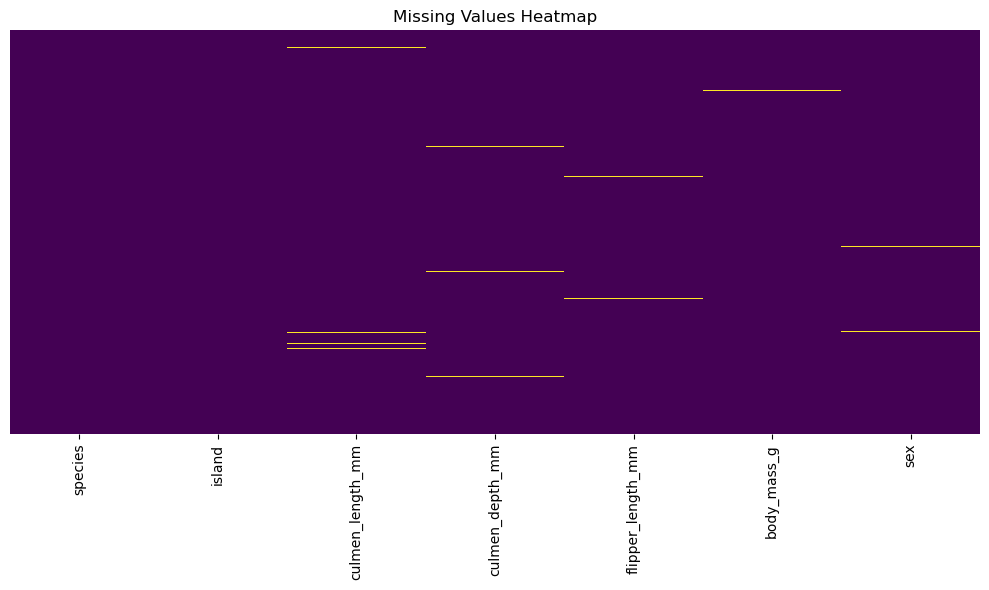

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

### Duplicate Rows

In [10]:
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')
if dup_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()[0]))

Number of duplicate rows: 0


## Automated Profiling Report

In [11]:
from pathlib import Path
from data_profiling import ProfileReport

report_dir = Path("EDA report")
report_dir.mkdir(parents=True, exist_ok=True)

profile = ProfileReport(df, title="EDA Report")
profile.to_file(report_dir / "eda_report.html")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 293.72it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Exploratory Data Analysis

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = "species"
numerical_cols = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]
categorical_cols = ["island", "sex"]
classes = sorted(df[target_col].dropna().unique())

plot_dir = report_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, name):
    fig.savefig(plot_dir / name, bbox_inches="tight", dpi=150)
    plt.show()

### Numerical Features vs Species

#### culmen_length_mm

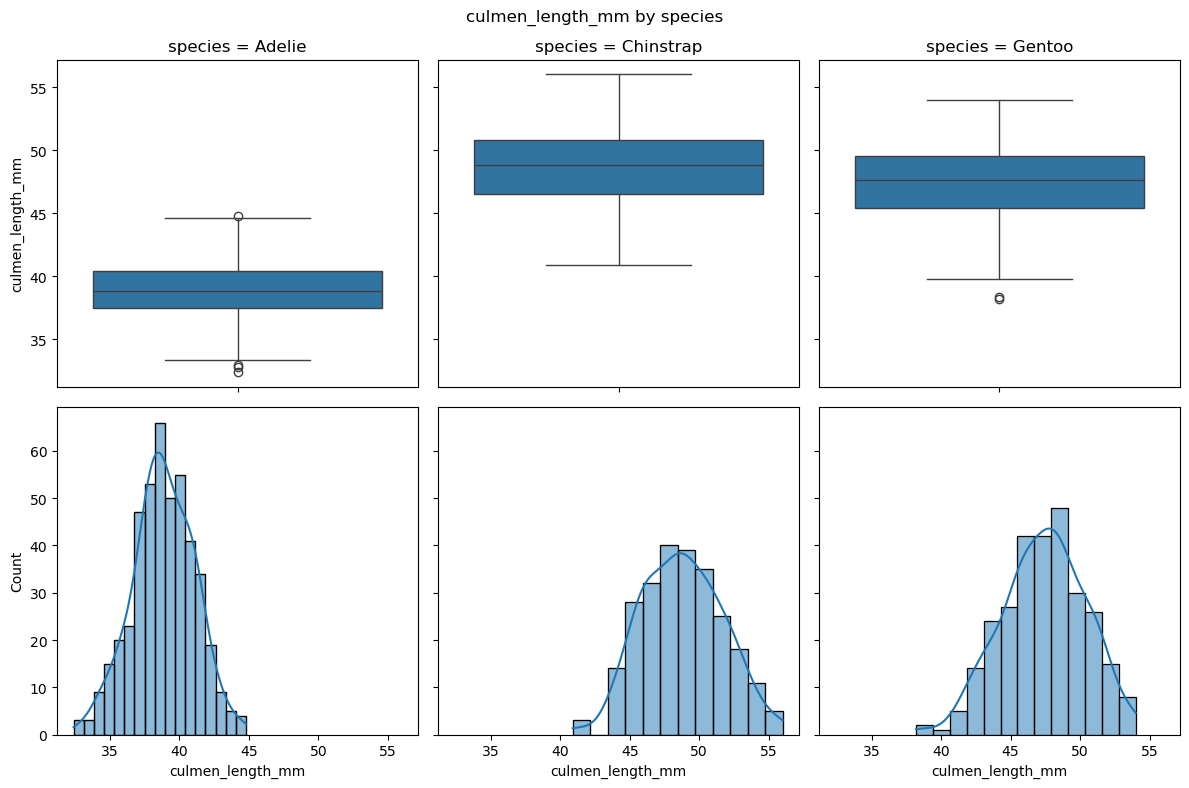

In [13]:
col = "culmen_length_mm"
n = len(classes)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8), sharex="row", sharey="row")
if n == 1:
    axes = axes.reshape(2, 1)

for j, cls in enumerate(classes):
    subset = df.loc[df[target_col] == cls, col]

    sns.boxplot(y=subset, ax=axes[0, j])
    axes[0, j].set_title(f"{target_col} = {cls}")
    axes[0, j].set_xlabel("")

    sns.histplot(subset, kde=True, ax=axes[1, j])
    axes[1, j].set_xlabel(col)

fig.suptitle(f"{col} by {target_col}")
fig.tight_layout()
save_and_show(fig, f"{col}_by_{target_col}.png")

#### culmen_depth_mm

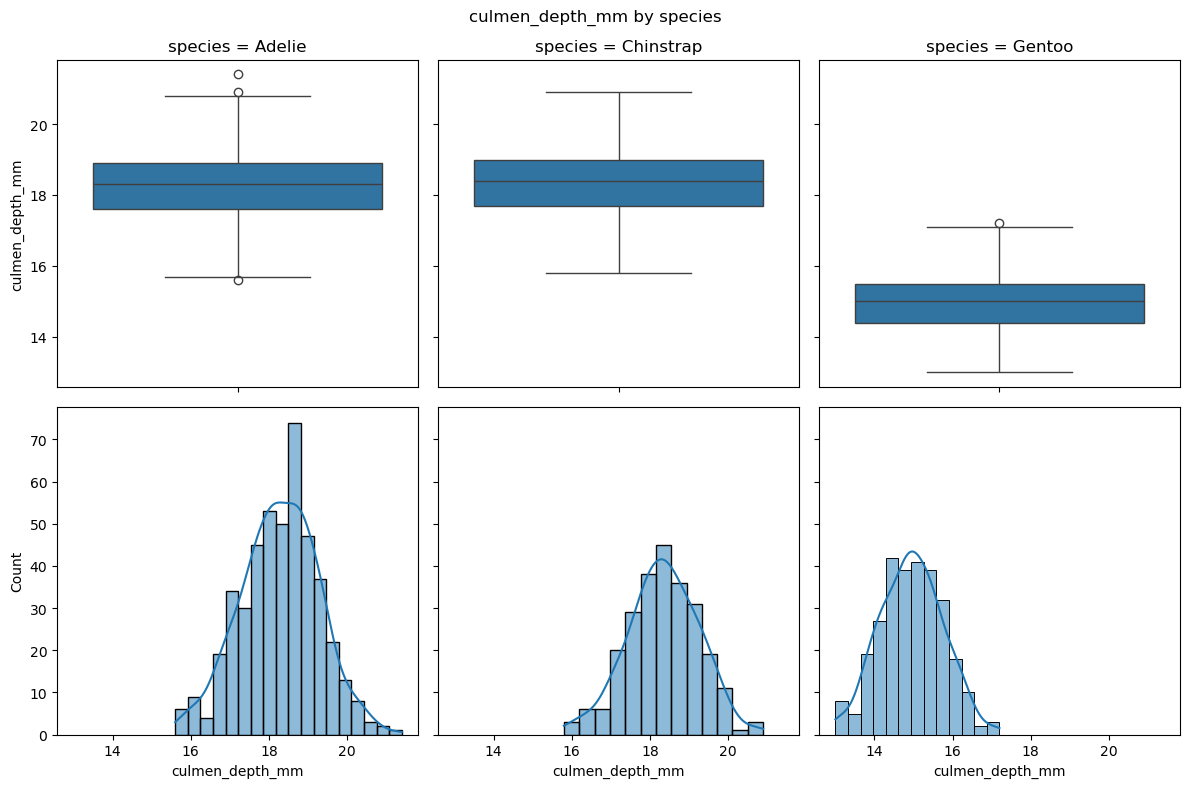

In [14]:
col = "culmen_depth_mm"
n = len(classes)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8), sharex="row", sharey="row")
if n == 1:
    axes = axes.reshape(2, 1)

for j, cls in enumerate(classes):
    subset = df.loc[df[target_col] == cls, col]

    sns.boxplot(y=subset, ax=axes[0, j])
    axes[0, j].set_title(f"{target_col} = {cls}")
    axes[0, j].set_xlabel("")

    sns.histplot(subset, kde=True, ax=axes[1, j])
    axes[1, j].set_xlabel(col)

fig.suptitle(f"{col} by {target_col}")
fig.tight_layout()
save_and_show(fig, f"{col}_by_{target_col}.png")

#### flipper_length_mm

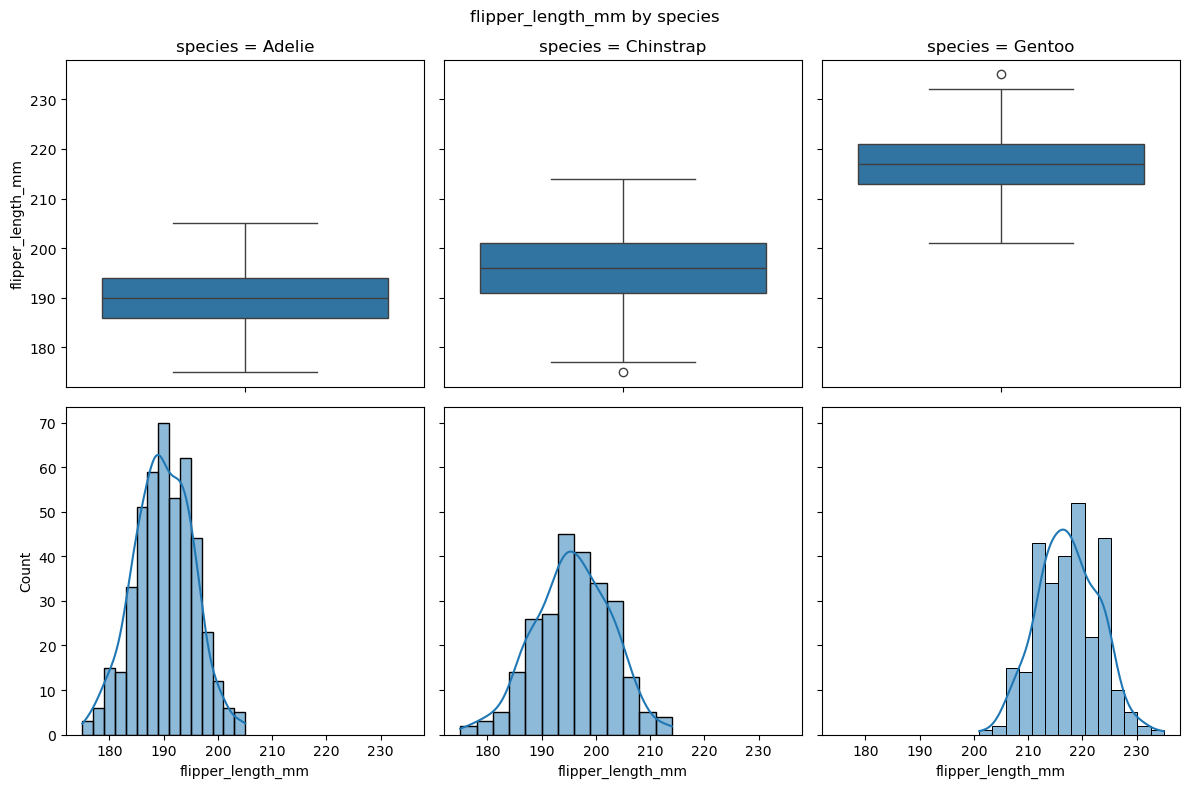

In [15]:
col = "flipper_length_mm"
n = len(classes)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8), sharex="row", sharey="row")
if n == 1:
    axes = axes.reshape(2, 1)

for j, cls in enumerate(classes):
    subset = df.loc[df[target_col] == cls, col]

    sns.boxplot(y=subset, ax=axes[0, j])
    axes[0, j].set_title(f"{target_col} = {cls}")
    axes[0, j].set_xlabel("")

    sns.histplot(subset, kde=True, ax=axes[1, j])
    axes[1, j].set_xlabel(col)

fig.suptitle(f"{col} by {target_col}")
fig.tight_layout()
save_and_show(fig, f"{col}_by_{target_col}.png")

#### body_mass_g

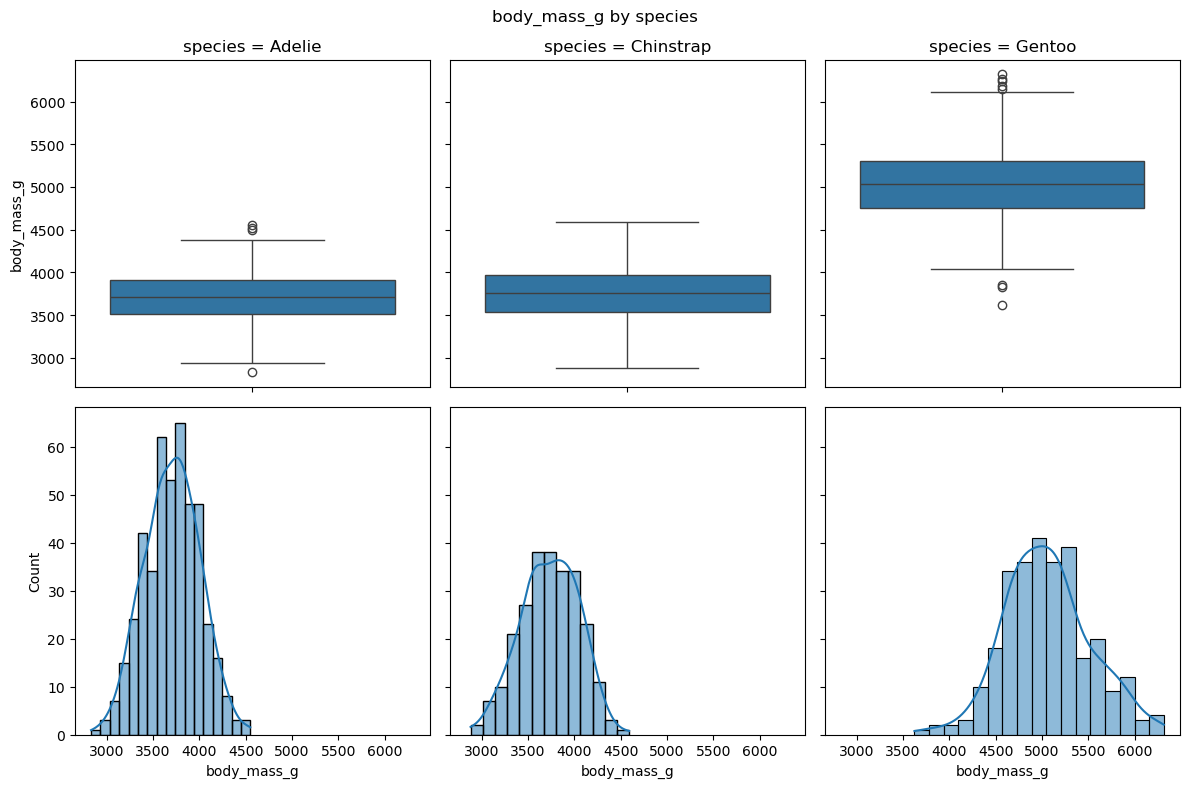

In [16]:
col = "body_mass_g"
n = len(classes)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8), sharex="row", sharey="row")
if n == 1:
    axes = axes.reshape(2, 1)

for j, cls in enumerate(classes):
    subset = df.loc[df[target_col] == cls, col]

    sns.boxplot(y=subset, ax=axes[0, j])
    axes[0, j].set_title(f"{target_col} = {cls}")
    axes[0, j].set_xlabel("")

    sns.histplot(subset, kde=True, ax=axes[1, j])
    axes[1, j].set_xlabel(col)

fig.suptitle(f"{col} by {target_col}")
fig.tight_layout()
save_and_show(fig, f"{col}_by_{target_col}.png")

### Categorical Features vs Species

#### island

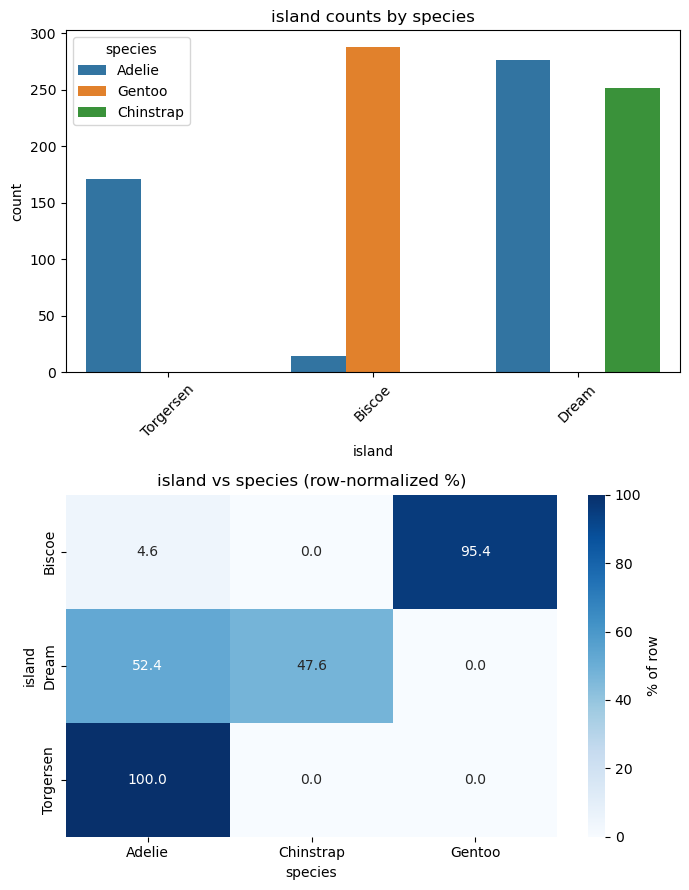

In [17]:
col = "island"
fig, axes = plt.subplots(2, 1, figsize=(7, 9))

sns.countplot(data=df, x=col, hue=target_col, ax=axes[0])
axes[0].set_title(f"{col} counts by {target_col}")
axes[0].tick_params(axis="x", rotation=45)

ct = pd.crosstab(df[col], df[target_col], normalize="index") * 100
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues",
            cbar_kws={"label": "% of row"}, ax=axes[1])
axes[1].set_title(f"{col} vs {target_col} (row-normalized %)")
axes[1].set_ylabel(col)

fig.tight_layout()
save_and_show(fig, f"{col}_panel.png")

#### sex

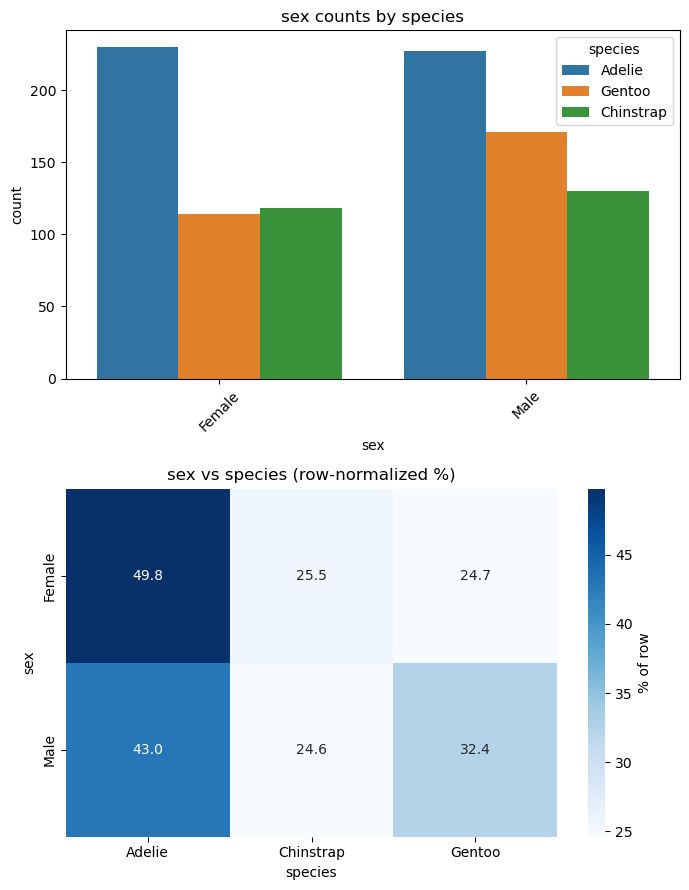

In [18]:
col = "sex"
fig, axes = plt.subplots(2, 1, figsize=(7, 9))

sns.countplot(data=df, x=col, hue=target_col, ax=axes[0])
axes[0].set_title(f"{col} counts by {target_col}")
axes[0].tick_params(axis="x", rotation=45)

ct = pd.crosstab(df[col], df[target_col], normalize="index") * 100
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues",
            cbar_kws={"label": "% of row"}, ax=axes[1])
axes[1].set_title(f"{col} vs {target_col} (row-normalized %)")
axes[1].set_ylabel(col)

fig.tight_layout()
save_and_show(fig, f"{col}_panel.png")

## Categorical Data Cleaning

The categorical columns in this dataset are `species` (target), `island`, and `sex`. The steps below check each of the standard categorical data-quality issues (missing values, formatting, spelling variants, invalid categories, distribution, cardinality, rare categories, and domain consistency) against the real data.

### Step 1: Missing / Unknown Values

Checking each categorical column for real nulls as well as placeholder junk that means "missing" without being `NaN` (empty strings, `"NA"`, `"unknown"`, `"?"`, etc.).

In [19]:
cat_cols = ['species', 'island', 'sex']
placeholder_junk = {'', 'na', 'n/a', 'none', 'null', '-', 'unknown', '?', '9999'}

missing_report = []
for col in cat_cols:
    null_count = df[col].isnull().sum()
    null_pct = null_count / len(df) * 100
    junk_mask = df[col].dropna().astype(str).str.strip().str.lower().isin(placeholder_junk)
    missing_report.append({
        'column': col,
        'null_count': null_count,
        'null_pct': round(null_pct, 2),
        'placeholder_junk_count': int(junk_mask.sum()),
    })

pd.DataFrame(missing_report)

,column,null_count,null_pct,placeholder_junk_count
0,species,0,0.0,0
1,island,0,0.0,0
2,sex,10,1.0,0


### Step 2: Standardize Formatting

Trimming whitespace and collapsing internal double-spaces. This is safe to apply directly since it can't change what a value means — only how it's written.

In [20]:
formatting_changes = {}
for col in cat_cols:
    before = df[col].copy()
    df[col] = df[col].str.strip().str.replace(r'\s+', ' ', regex=True)
    changed = ((before != df[col]) & before.notna()).sum()
    formatting_changes[col] = int(changed)

formatting_changes

{'species': 0, 'island': 0, 'sex': 0}

### Step 3: Standardize Category Names (Spelling / Abbreviations / Synonyms)

Using fuzzy string matching to flag values within each column that are likely the same real-world category written differently (typos, abbreviations, synonyms).

In [21]:
from difflib import get_close_matches

near_duplicates = {}
for col in cat_cols:
    uniques = df[col].dropna().unique().tolist()
    flagged = []
    for v in uniques:
        others = [u for u in uniques if u != v]
        matches = get_close_matches(v, others, n=1, cutoff=0.75)
        if matches:
            flagged.append((v, matches[0]))
    near_duplicates[col] = flagged if flagged else 'none found'

near_duplicates

{'species': 'none found', 'island': 'none found', 'sex': 'none found'}

### Step 4: Validate Categories

Checking observed values against the known valid categories for this domain (the Palmer Archipelago penguins dataset: 3 species, 3 islands, 2 sexes).

In [22]:
valid_categories = {
    'species': {'Adelie', 'Gentoo', 'Chinstrap'},
    'island': {'Biscoe', 'Dream', 'Torgersen'},
    'sex': {'Male', 'Female'},
}

invalid_report = {}
for col, valid in valid_categories.items():
    observed = set(df[col].dropna().unique())
    invalid = observed - valid
    invalid_report[col] = invalid if invalid else 'none found'

invalid_report

{'species': 'none found', 'island': 'none found', 'sex': 'none found'}

### Step 5: Category Distribution

In [23]:
for col in cat_cols:
    counts = df[col].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(1)
    print(f"--- {col} ---")
    display(pd.DataFrame({'count': counts, 'pct': pct}))

--- species ---


,count,pct
species,,
Adelie,461,46.1
Gentoo,288,28.8
Chinstrap,251,25.1


--- island ---


,count,pct
island,,
Dream,527,52.7
Biscoe,302,30.2
Torgersen,171,17.1


--- sex ---


,count,pct
sex,,
Male,528,52.8
Female,462,46.2
NaN,10,1.0


### Step 6: Cardinality Check

In [24]:
df[cat_cols].nunique(dropna=True)

species    3
island     3
sex        2
dtype: int64

### Step 7: Rare / High-Cardinality Categories

Flagging any category below 5% of rows within its column as a candidate for grouping.

In [25]:
rare_threshold_pct = 5

rare_report = {}
for col in cat_cols:
    counts = df[col].value_counts(dropna=True)
    pct = counts / counts.sum() * 100
    rare = pct[pct < rare_threshold_pct]
    rare_report[col] = rare.to_dict() if not rare.empty else 'none found'

rare_report

{'species': 'none found', 'island': 'none found', 'sex': 'none found'}

### Step 8: Verify Consistency With Domain Knowledge

`species` (Adelie, Chinstrap, Gentoo) and `island` (Biscoe, Dream, Torgersen) match exactly the three penguin species and three islands documented in the well-known Palmer Archipelago penguins dataset that this data derives from. `sex` is binary (Male/Female) as expected for a biological sex field. No unexpected or out-of-domain categories were found in Step 4.

### Missing Value Decision — `sex`

The 10 missing `sex` values (1% of rows) are left as `np.nan` rather than imputed or dropped — sex can't be reliably inferred from bill/flipper/body-mass measurements alone, and 1% of rows isn't worth discarding. No code change is needed; this simply confirms nothing downstream has silently filled or removed them.

In [26]:
assert df['sex'].isnull().sum() == 10
df['sex'].isnull().sum()

10

### Convert to `category` dtype

Converting `species`, `island`, and `sex` to pandas `category` dtype — more memory-efficient, and the dtype tree-based models like XGBoost/LightGBM (`enable_categorical=True`) and CatBoost expect to natively recognize a column as categorical.

In [27]:
df[cat_cols] = df[cat_cols].astype('category')
df[cat_cols].dtypes

species    category
island     category
sex        category
dtype: object

### Final Check — Cleaned Categorical Columns

In [28]:
for col in cat_cols:
    print(f"--- {col} ({df[col].dtype}) ---")
    print(df[col].value_counts(dropna=False))
    print()

--- species (category) ---
species
Adelie       461
Gentoo       288
Chinstrap    251
Name: count, dtype: int64

--- island (category) ---
island
Dream        527
Biscoe       302
Torgersen    171
Name: count, dtype: int64

--- sex (category) ---
sex
Male      528
Female    462
NaN        10
Name: count, dtype: int64



## Numerical Data Cleaning

The numerical columns in this dataset are `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, and `body_mass_g` (all `float64`). The steps below check each of the standard numerical data-quality issues (missing values, dtypes, impossible values, outliers, duplicates, distributions, units, extremes, transformations, and domain consistency) against the real data.

### Step 1: Missing Values

10 missing values (1.0%) in each of the 4 numerical columns, scattered mostly across different rows (see the Missing Values check earlier in the notebook and `Feature_Description.md`).

**Decision:** leave these as `np.nan` rather than imputing or dropping. Same rationale as the `sex` column: 1% per column isn't worth discarding rows over, imputing a bill/flipper/mass measurement risks inventing a value that wasn't observed, and XGBoost/LightGBM (the planned downstream models) handle `NaN` natively without needing it filled.

In [29]:
num_cols = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]

num_missing = df[num_cols].isnull().sum()
num_missing_pct = (num_missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': num_missing, 'missing_pct': num_missing_pct})

,missing_count,missing_pct
culmen_length_mm,10,1.0
culmen_depth_mm,10,1.0
flipper_length_mm,10,1.0
body_mass_g,10,1.0


### Step 2: Data Types

All 4 columns are already `float64`. There are no numeric-looking values stored as strings/objects and nothing here should be an integer or datetime instead — no dtype correction needed.

In [30]:
df[num_cols].dtypes

culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
dtype: object

### Step 3: Impossible / Invalid Values

Checking for negative or zero values, which would be physically impossible for a bill length/depth, flipper length, or body mass.

In [31]:
invalid_report = pd.DataFrame({
    'negative_count': [(df[c] < 0).sum() for c in num_cols],
    'zero_count': [(df[c] == 0).sum() for c in num_cols],
}, index=num_cols)
invalid_report

,negative_count,zero_count
culmen_length_mm,0,0
culmen_depth_mm,0,0
flipper_length_mm,0,0
body_mass_g,0,0


### Step 4: Outlier Detection

Using the IQR method (1.5×IQR beyond Q1/Q3). Run twice: once across the whole dataset, and once per species, since `species` is known for every row and body size genuinely differs by species (a large Gentoo is not an "outlier" the way a large Adelie would be) — a whole-dataset IQR can mistake a species effect for an anomaly.

In [32]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum(), round(lo, 2), round(hi, 2)

print("--- Whole-dataset IQR ---")
for c in num_cols:
    n_out, lo, hi = iqr_outlier_count(df[c].dropna())
    print(f"{c}: bounds=({lo}, {hi}), outliers={n_out}")

print("\n--- Per-species IQR ---")
per_species_outliers = {}
for c in num_cols:
    total = 0
    for sp, g in df.groupby('species', observed=True):
        n_out, lo, hi = iqr_outlier_count(g[c].dropna())
        total += n_out
    per_species_outliers[c] = total
    print(f"{c}: total outliers across species = {total}")

--- Whole-dataset IQR ---
culmen_length_mm: bounds=(25.05, 62.25), outliers=0
culmen_depth_mm: bounds=(11.45, 23.05), outliers=0
flipper_length_mm: bounds=(154.5, 246.5), outliers=0
body_mass_g: bounds=(2084.5, 6088.5), outliers=6

--- Per-species IQR ---
culmen_length_mm: total outliers across species = 6
culmen_depth_mm: total outliers across species = 4
flipper_length_mm: total outliers across species = 2
body_mass_g: total outliers across species = 12


**Decision:** keep all values as-is, no capping or removal. The whole-dataset outliers in `body_mass_g` are all Gentoo penguins near the top of their normal range (up to 6317g, consistent with Gentoo reaching ~6300g in the well-known Palmer Archipelago source data) — a species effect, not an error. The per-species check still flags a handful of mild outliers per column (2-12 rows total across the 3 species), but none look like data-entry errors: no impossible values, no values outside plausible biological ranges, just the normal tails of each species' distribution.

### Step 5: Duplicate Values

Full-row duplicates were already checked earlier in the notebook (0 found). Checking here specifically on just the 4 numerical columns, in case two different penguins happen to share identical measurements.

In [33]:
num_dup_count = df.duplicated(subset=num_cols).sum()
print(f'Duplicate rows on numerical columns only: {num_dup_count}')

Duplicate rows on numerical columns only: 0


### Step 6: Value Ranges & Distributions

Per-species min/max/mean, alongside the shape plots already produced in the Exploratory Data Analysis section above (boxplot + histogram per species for each column).

In [34]:
df.groupby('species', observed=True)[num_cols].agg(['min', 'max', 'mean']).round(2)

culmen_length_mm              culmen_depth_mm               \
                       min   max   mean             min   max   mean   
species                                                                
Adelie                32.4  44.8  38.87            15.6  21.4  18.28   
Chinstrap             40.9  56.0  48.80            15.8  20.9  18.34   
Gentoo                38.2  54.0  47.39            13.0  17.2  14.95   

          flipper_length_mm                body_mass_g                   
                        min    max    mean         min     max     mean  
species                                                                  
Adelie                175.0  205.0  189.85      2830.0  4550.0  3705.11  
Chinstrap             175.0  214.0  195.64      2879.0  4591.0  3733.94  
Gentoo                201.0  235.0  217.35      3623.0  6317.0  5058.39

### Step 7: Inconsistent Units / Scales

Not applicable here — there's a single column per measurement (no duplicate "imperial" columns to reconcile), and the per-species ranges above show each column occupying one consistent, plausible scale (e.g. no `body_mass_g` values in the single or low-double digits that would suggest a stray kg reading mixed into the grams column). Skipping; nothing to standardize.

### Step 8: Suspicious / Extreme Values

Checking measurement precision as an extra sanity signal: flipper length and body mass are whole numbers in this data (consistent with typical field-measurement precision to the nearest mm/g), while bill length/depth carry one decimal place (consistent with caliper measurements to 0.1mm) — no column mixes precisions in a way that would suggest merged sources or unit drift.

In [35]:
precision_check = {}
for c in num_cols:
    non_integer_count = (df[c].dropna() % 1 != 0).sum()
    precision_check[c] = non_integer_count
pd.Series(precision_check, name='non_integer_value_count')

culmen_length_mm     878
culmen_depth_mm      874
flipper_length_mm      0
body_mass_g            0
Name: non_integer_value_count, dtype: int64

### Step 9: Transformations

**Decision:** no transformation (no log, no scaling). Distributions above are roughly unimodal per species with no extreme skew, and the categorical columns were already converted to `category` dtype specifically to feed tree-based models (XGBoost/LightGBM), which are invariant to monotonic transforms and feature scale — scaling or log-transforming these columns would add a step with no modeling benefit and would reduce interpretability of the raw measurements.

### Step 10: Verify Consistency With Domain Knowledge

All 4 columns' per-species ranges (Step 6) line up with the well-known Palmer Archipelago penguins reference ranges: Adelie/Chinstrap culmen length in the high-30s/low-40s to high-40s/low-50s, Gentoo distinctly longer-billed-but-shallower and heavier, flipper length increasing Adelie < Chinstrap < Gentoo, and body mass Gentoo well above the other two — matching the expected biology (Gentoo is the largest of the three species, Adelie the smallest-billed). Nothing here needed to be flagged back to the user as implausible.

### Final Check — Numerical Columns

In [36]:
df[num_cols].describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,990.000000,990.000000,990.000000,990.000000
mean,43.817778,17.335556,199.224242,4103.311111
std,5.309985,1.779057,13.171660,705.334794
min,32.400000,13.000000,175.000000,2830.000000
25%,39.000000,15.800000,189.000000,3586.000000
50%,43.800000,17.800000,195.000000,3882.000000
75%,48.300000,18.700000,212.000000,4587.000000
max,56.000000,21.400000,235.000000,6317.000000


## Train/Test Split

In [37]:
print("df shape:", df.shape)
df.head()

df shape: (1000, 7)


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


In [38]:
X = df.drop(columns=["species"])
y = df["species"]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [40]:
print("X_train shape:", X_train.shape)
X_train.head()

X_train shape: (800, 6)


,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
357,Dream,46.3,17.8,188.0,3495.0,Male
945,Dream,35.0,19.6,205.0,3714.0,Female
921,Dream,45.6,18.1,187.0,4016.0,Female
484,Dream,48.7,18.6,203.0,3757.0,Female
594,Biscoe,45.7,13.9,214.0,4931.0,Female


In [41]:
print("X_test shape:", X_test.shape)
X_test.head()

X_test shape: (200, 6)


,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
178,Biscoe,48.7,14.8,221.0,5905.0,Male
223,Torgersen,44.6,16.8,192.0,3840.0,Female
836,Biscoe,42.0,14.4,209.0,5817.0,Male
75,Biscoe,49.5,15.5,215.0,5226.0,Female
917,Biscoe,49.3,13.2,213.0,4698.0,Female


In [42]:
print("y_train shape:", y_train.shape)
print(y_train.value_counts())

y_train shape: (800,)
species
Adelie       369
Gentoo       230
Chinstrap    201
Name: count, dtype: int64


In [43]:
print("y_test shape:", y_test.shape)
print(y_test.value_counts())

y_test shape: (200,)
species
Adelie       92
Gentoo       58
Chinstrap    50
Name: count, dtype: int64


## Label Encoding — Target (`species`)

Encoding the `species` target with `LabelEncoder`, fit on `y_train` only so nothing from `y_test` leaks into the encoder, then reused to transform `y_test`.

In [44]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Fit on the training target only, so nothing from test leaks into the encoder
y_train = label_encoder.fit_transform(y_train)

# Reuse the training mapping for the test target
y_test = label_encoder.transform(y_test)

### Class Mapping

In [45]:
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(mapping)

{'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}


## Initial XGBoost Model

Baseline multiclass `XGBClassifier` (XGBoost defaults, no hyperparameter tuning) evaluated with 5-fold `StratifiedKFold` cross-validation on the training split only (`X_train`, `y_train`). `island` and `sex` are passed as native categoricals (`enable_categorical=True`); `random_state=42` is used for both the model and the CV splitter.

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import average_precision_score, make_scorer
from xgboost import XGBClassifier

CATEGORICAL_COLUMNS = ["island", "sex"]
RANDOM_STATE = 42
N_FOLDS = 5

# Cast only columns that aren't already 'category' (keeps existing category metadata intact)
for col in CATEGORICAL_COLUMNS:
    if not isinstance(X_train[col].dtype, pd.CategoricalDtype):
        X_train[col] = X_train[col].astype("category")

X_train.dtypes

island               category
culmen_length_mm      float64
culmen_depth_mm       float64
flipper_length_mm     float64
body_mass_g           float64
sex                  category
dtype: object

In [ ]:
model = XGBClassifier(random_state=RANDOM_STATE, enable_categorical=True)
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Multiclass: macro-averaged precision/recall/F1, one-vs-rest ROC-AUC, macro PR-AUC
pr_auc_macro_scorer = make_scorer(
    average_precision_score, average="macro", response_method="predict_proba"
)
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc_ovr",
    "pr_auc_macro": pr_auc_macro_scorer,
}

In [ ]:
cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)

In [ ]:
rows = []
for metric_name in scoring:
    scores = cv_results[f"test_{metric_name}"]
    rows.append({
        "metric": metric_name,
        "fold_scores": np.round(scores, 4).tolist(),
        "mean": round(scores.mean(), 4),
        "std": round(scores.std(), 4),
    })
summary_df = pd.DataFrame(rows)
print("Per-fold metrics (mean ± std):")
print(summary_df.to_string(index=False))

Per-fold metrics (mean ± std):
         metric                           fold_scores   mean    std
       accuracy  [0.975, 0.9875, 0.9875, 0.9812, 1.0] 0.9862 0.0083
precision_macro  [0.972, 0.9872, 0.9912, 0.9826, 1.0] 0.9866 0.0093
   recall_macro [0.9782, 0.9872, 0.9833, 0.9788, 1.0] 0.9855 0.0079
       f1_macro  [0.9749, 0.9872, 0.987, 0.9806, 1.0] 0.9859 0.0084
        roc_auc [0.9958, 0.9999, 0.9998, 0.9921, 1.0] 0.9975 0.0031
   pr_auc_macro [0.9917, 0.9997, 0.9995, 0.9906, 1.0] 0.9963 0.0042


In [ ]:
# Fit on the full training set so the model is available for later steps
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)